# Near-time Forecasting

## Recalculating Features

In [1]:
import pandas as pd
csv_file_path = 'data/energy_data_new.csv'
df = (pd.read_csv(csv_file_path, parse_dates=['period'])
      .set_index('period')
      .sort_index(ascending=False))
df = df.tail(-81)
df


,subba,subba-name,parent,parent-name,value,value-units
period,,,,,,
2024-04-04 14:00:00,ZONJ,New York City,NYIS,New York Independent System Operator,5752,megawatthours
2024-04-04 13:00:00,ZONJ,New York City,NYIS,New York Independent System Operator,5630,megawatthours
2024-04-04 12:00:00,ZONJ,New York City,NYIS,New York Independent System Operator,5420,megawatthours
2024-04-04 11:00:00,ZONJ,New York City,NYIS,New York Independent System Operator,4989,megawatthours
2024-04-04 10:00:00,ZONJ,New York City,NYIS,New York Independent System Operator,4567,megawatthours
...,...,...,...,...,...,...
2024-01-01 04:00:00,ZONJ,New York City,NYIS,New York Independent System Operator,4956,megawatthours
2024-01-01 03:00:00,ZONJ,New York City,NYIS,New York Independent System Operator,5112,megawatthours
2024-01-01 02:00:00,ZONJ,New York City,NYIS,New York Independent System Operator,5257,megawatthours


In [2]:
df.index.min(), df.index.max()

(Timestamp('2024-01-01 00:00:00'), Timestamp('2024-04-04 14:00:00'))

In [3]:

import yaml
import os
directory = "feature_store"
yaml_file_path = os.path.join(directory, 'config_v1.yaml')
with open(yaml_file_path, 'r') as file:
    config = yaml.safe_load(file)

max_offset_days = int(config['feature_store']['feature_offset'])

print(max_offset_days)


13


In [4]:
max_offset_hours = (max_offset_days + 1) * 24 # +1 because we need the current day + the offset
max_offset_hours

336

In [5]:
# Get one mini-batch of data
mini_batch_df = df[:max_offset_hours]
mini_batch_df


,subba,subba-name,parent,parent-name,value,value-units
period,,,,,,
2024-04-04 14:00:00,ZONJ,New York City,NYIS,New York Independent System Operator,5752,megawatthours
2024-04-04 13:00:00,ZONJ,New York City,NYIS,New York Independent System Operator,5630,megawatthours
2024-04-04 12:00:00,ZONJ,New York City,NYIS,New York Independent System Operator,5420,megawatthours
2024-04-04 11:00:00,ZONJ,New York City,NYIS,New York Independent System Operator,4989,megawatthours
2024-04-04 10:00:00,ZONJ,New York City,NYIS,New York Independent System Operator,4567,megawatthours
...,...,...,...,...,...,...
2024-03-21 19:00:00,ZONJ,New York City,NYIS,New York Independent System Operator,5767,megawatthours
2024-03-21 18:00:00,ZONJ,New York City,NYIS,New York Independent System Operator,5816,megawatthours
2024-03-21 17:00:00,ZONJ,New York City,NYIS,New York Independent System Operator,5852,megawatthours


In [13]:
chunk_size = 24
periods = mini_batch_df.index[::chunk_size]  # Select every chunk_size-th index as the period
sums = [mini_batch_df.iloc[i:i + chunk_size]['value'].sum() for i in range(0, len(mini_batch_df), chunk_size)]
resampled_df = pd.DataFrame({'period': periods, 'value': sums})
resampled_df.set_index('period', inplace=True)
resampled_df


,value
period,
2024-04-04 14:00:00,131001
2024-04-03 14:00:00,126545
2024-04-02 14:00:00,122018
2024-04-01 14:00:00,110076
2024-03-31 14:00:00,109811
2024-03-30 14:00:00,118276
2024-03-29 14:00:00,125478
2024-03-28 14:00:00,125171
2024-03-27 14:00:00,124573


<Axes: xlabel='period'>

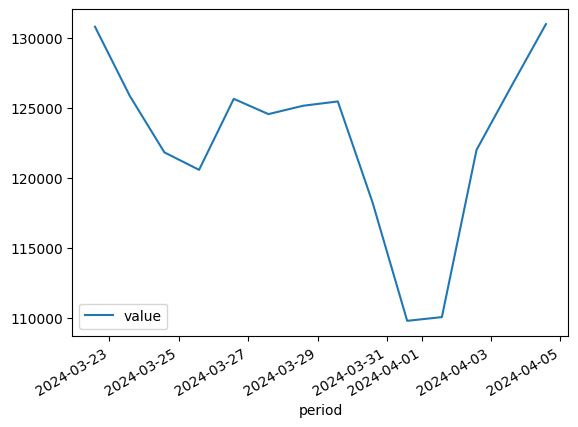

In [14]:
resampled_df.plot()

In [17]:

# Recalculating features

def feature_pipeline_online(mini_batch_df):
    
    # Resample the last 24 hours relatively
    chunk_size = 24
    periods = mini_batch_df.index[::chunk_size]  # Select every chunk_size-th index as the period
    sums = [mini_batch_df.iloc[i:i + chunk_size]['value'].sum() for i in range(0, len(mini_batch_df), chunk_size)]
    resampled_df = pd.DataFrame({'period': periods, 'value': sums})
    resampled_df.set_index('period', inplace=True)
    resampled_df = resampled_df.sort_index(ascending = True)
    print(resampled_df.shape)

    batch_df = pd.DataFrame()

    # Lagging features
    batch_df['lag_1'] = resampled_df['value'].shift(1) # Energy demand -1 day

    batch_df['lag_4'] = resampled_df['value'].shift(4) # Energy demand +3 days - 7 days
    batch_df['lag_5'] = resampled_df['value'].shift(5) # Energy demand +2 days - 7 days
    batch_df['lag_6'] = resampled_df['value'].shift(6) # Energy demand +1 days - 7 days

    batch_df['lag_11'] = resampled_df['value'].shift(11) # Energy demand +3 days - 14 days
    batch_df['lag_12'] = resampled_df['value'].shift(12) # Energy demand +2 days - 14 days
    batch_df['lag_13'] = resampled_df['value'].shift(13) # Energy demand +1 days - 14 days

    # Rolling statistics
    batch_df['rolling_mean_7'] = resampled_df['value'].rolling(window=7).mean().round(2)
    batch_df['rolling_std_7'] = resampled_df['value'].rolling(window=7).std().round(2) 
    
    batch_df = batch_df.dropna()
    
    return batch_df


In [18]:

feature_pipeline_online(mini_batch_df)


(14, 1)


,lag_1,lag_4,lag_5,lag_6,lag_11,lag_12,lag_13,rolling_mean_7,rolling_std_7
period,,,,,,,,,
2024-04-04 14:00:00,126545.0,109811.0,118276.0,125478.0,121841.0,125884.0,130810.0,120457.86,8182.77


In [22]:

# try with some new data
datetime = "2024-04-03 10:00:00"
csv_file_path = 'data/energy_data_new.csv'

# This could also be a SQL statement
mini_batch_df = (pd.read_csv(csv_file_path, parse_dates=['period'])
      .set_index('period')
      .sort_index(ascending=False)
      .query("period <= @datetime"))[:max_offset_hours]

print(mini_batch_df.shape)

# Process batch on the fly
feature_pipeline_online(mini_batch_df)


(336, 6)
(14, 1)


,lag_1,lag_4,lag_5,lag_6,lag_11,lag_12,lag_13,rolling_mean_7,rolling_std_7
period,,,,,,,,,
2024-04-03 10:00:00,121369.0,120419.0,126130.0,125423.0,129076.0,130762.0,126434.0,119585.43,7639.02
